In [9]:
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
from itertools import product

import sys

from pathlib import Path
nb_dir = Path.cwd()
help_func_path = os.path.join(nb_dir,'helper_code')

sys.path.append(help_func_path) 

from plotting_functions import scatter_helper, plot_3d_scatters
from saving_functions import save_dataset,delete_dataset

#### uses sklearn.datasets.make_blobs which samples from a GMM under the hood

In [10]:
from sklearn import datasets

perform an affine transform with a diagonal matrix on the GMM output -- stretch along different features / axes

diag matrix randomly generated from a lognormal

either have a shared diag matrix for all (homoskedastic), or have separate random ones for each cluster (heteroskedastic by design)

https://math.stackexchange.com/questions/332441/affine-transformation-applied-to-a-multivariate-gaussian-random-variable-what

## trying affine transform

In [11]:

def diagonal_affine_transform(X,y,sig,shared=True,seed=0):
    unique_labels = np.unique(y)    

    rng = np.random.default_rng(seed)
    n_feat = X.shape[1]

    s_shared = rng.lognormal(0, sig, size=n_feat)
    X_out = np.empty_like(X)
    
    # apply transform to each cluster separately
    for k in np.unique(y):
        m = y == k
        if shared:
            s = s_shared
        else:
            s = rng.lognormal(0, sig, size=n_feat)
            
        mu = X[m].mean(axis=0)
        X_out[m] = mu + (X[m] - mu) * s
    
    return X_out

# plot_3d_scatters(X,'',y=y)
# plot_3d_scatters(X_out,'',y=y)

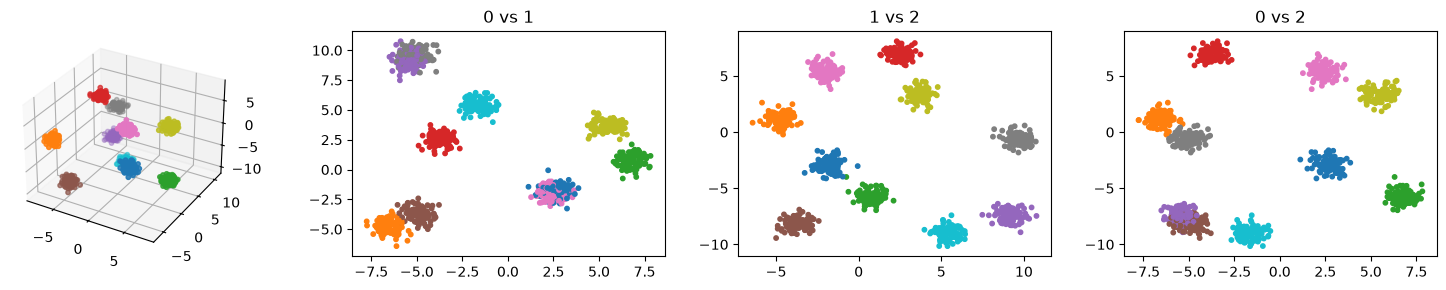

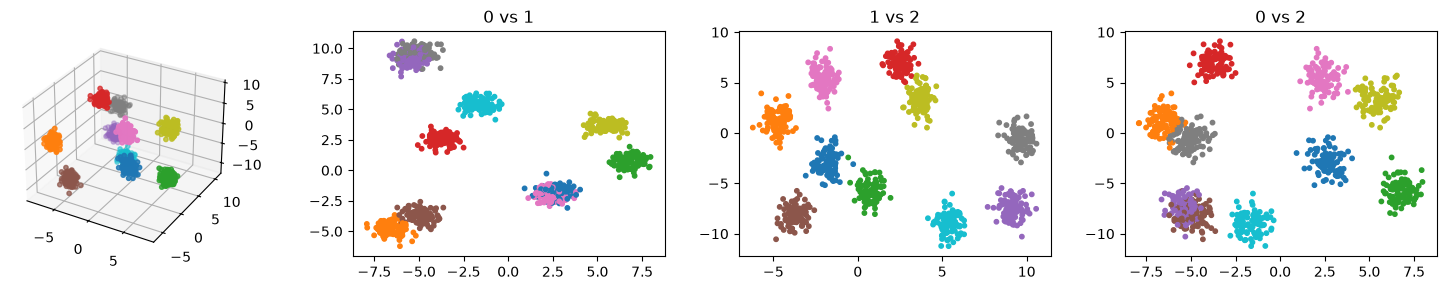

In [ ]:
X,y = datasets.make_blobs(n_samples=1000,n_features=1000, centers=10,cluster_std=0.5)
plot_3d_scatters(X,'',y=y)
X_out = diagonal_affine_transform(X,y,sig=1,shared=True,seed=0)
plot_3d_scatters(X_out,'',y=y)

In [ ]:
# delete_dataset('GMM_isotropic_homoskedastic_balanced','../all_data/')

## homoskedastic, balanced

In [14]:
data_gen_name = 'GMM_anisotropic_homoskedastic_balanced'
category_lst = ['blobbiness']

random_seeds_lst = [4,1980]

n_samples_lst = [1000,10000]
n_features_lst = [10,100,1000,10000]
# define some number of clusters according to the number of features
# {num_feature : [list of num_cluster params to sweep over]}
num_clusters_dict = {10 : [3,5,7], 100 : [3,10], 1000 : [3,10,40], 10000 : [3,10,40]}
cluster_std = 1.0
transform_sig_lst = [0.2,0.4,0.6,0.8,1]

for n_samples, n_features in product(n_samples_lst, n_features_lst):
    
    print(n_samples, n_features, X.shape)

    for n_centers in num_clusters_dict[n_features]:

        for transform_sig in transform_sig_lst:

            for sample_num,seed in enumerate(random_seeds_lst):
                
                X_iso, y = datasets.make_blobs(n_samples=n_samples,n_features=n_features, random_state=seed, centers=n_centers,cluster_std=cluster_std)
                transform_seed = seed+6
                X = diagonal_affine_transform(X_iso,y,sig=transform_sig,shared=True,seed=transform_seed)
                
                params_dict = {
                    'num_clusters': n_centers,
                    'cluster_std' : cluster_std,
                    'transform_diagonal_lognormal_sig' : transform_sig,
                    'shared_matrix_across_cluster' : True,                    
                    'transform_method' : 'generate lognormal diagonal matrix, apply affine transform, using diagonal_affine_transformation in this notebook',
                    'transform_seed' : transform_seed
                }
                
                extra_mtx_params = {
                    'cluster_labels' : y
                }
                
                try:
                    save_dataset(X, 
                                generator=data_gen_name,
                                params=params_dict,
                                seed=seed,
                                category=category_lst,
                                extra_arrays=extra_mtx_params, 
                                root='../all_data/')

                except:
                    print('error in saving')

1000 10 (1000, 1000)
1000 100 (1000, 10)
1000 1000 (1000, 100)
1000 10000 (1000, 1000)
10000 10 (1000, 10000)
10000 100 (10000, 10)
10000 1000 (10000, 100)
10000 10000 (10000, 1000)


In [30]:
m = pd.read_csv("../all_data/manifest.csv")
generator = 'GMM_anisotropic_homoskedastic_balanced'
params_lst = [f'params{i}' for i in range(0,20) if i%16==2]
m = m[(m.generator == generator) & (m.params_id.isin(params_lst))]
m

,dataset_id,generator,category,n_rows,n_cols,params_id,seed,extra_files
750,GMM_anisotropic_homoskedastic_balanced/params2...,GMM_anisotropic_homoskedastic_balanced,['blobbiness'],1000,10,params2,4,"[""cluster_labels_seed4.npy""]"
766,GMM_anisotropic_homoskedastic_balanced/params1...,GMM_anisotropic_homoskedastic_balanced,['blobbiness'],1000,10,params18,4,"[""cluster_labels_seed4.npy""]"
780,GMM_anisotropic_homoskedastic_balanced/params2...,GMM_anisotropic_homoskedastic_balanced,['blobbiness'],1000,100,params2,4,"[""cluster_labels_seed4.npy""]"
800,GMM_anisotropic_homoskedastic_balanced/params2...,GMM_anisotropic_homoskedastic_balanced,['blobbiness'],1000,1000,params2,4,"[""cluster_labels_seed4.npy""]"
830,GMM_anisotropic_homoskedastic_balanced/params2...,GMM_anisotropic_homoskedastic_balanced,['blobbiness'],1000,10000,params2,4,"[""cluster_labels_seed4.npy""]"
860,GMM_anisotropic_homoskedastic_balanced/params2...,GMM_anisotropic_homoskedastic_balanced,['blobbiness'],10000,10,params2,4,"[""cluster_labels_seed4.npy""]"
876,GMM_anisotropic_homoskedastic_balanced/params1...,GMM_anisotropic_homoskedastic_balanced,['blobbiness'],10000,10,params18,4,"[""cluster_labels_seed4.npy""]"
890,GMM_anisotropic_homoskedastic_balanced/params2...,GMM_anisotropic_homoskedastic_balanced,['blobbiness'],10000,100,params2,4,"[""cluster_labels_seed4.npy""]"
910,GMM_anisotropic_homoskedastic_balanced/params2...,GMM_anisotropic_homoskedastic_balanced,['blobbiness'],10000,1000,params2,4,"[""cluster_labels_seed4.npy""]"
940,GMM_anisotropic_homoskedastic_balanced/params2...,GMM_anisotropic_homoskedastic_balanced,['blobbiness'],10000,10000,params2,4,"[""cluster_labels_seed4.npy""]"


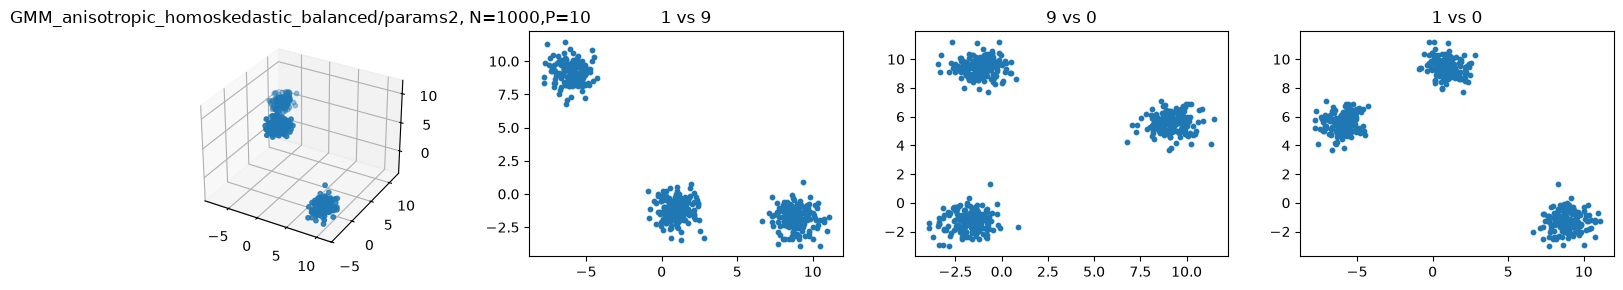

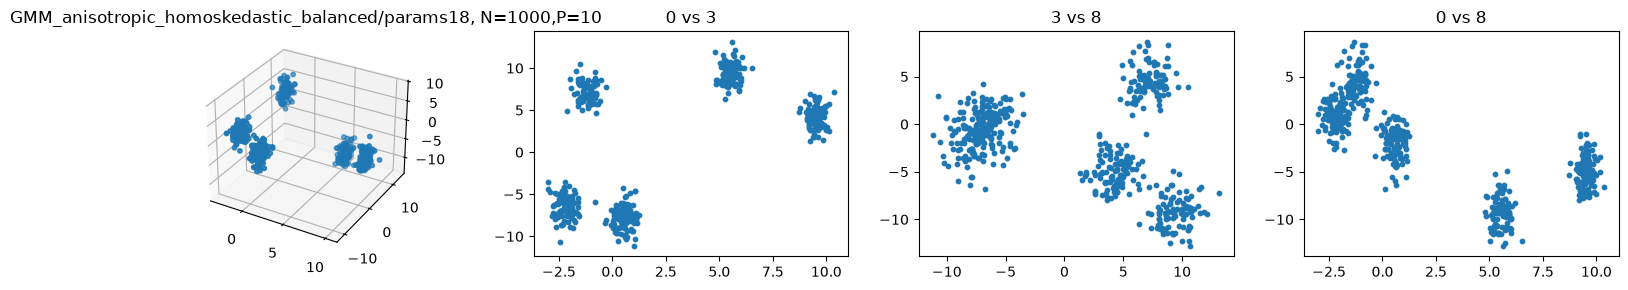

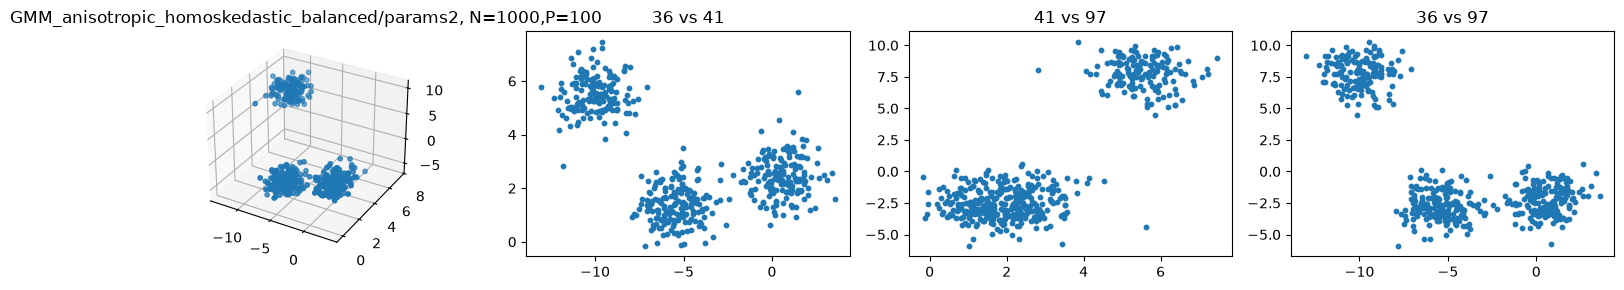

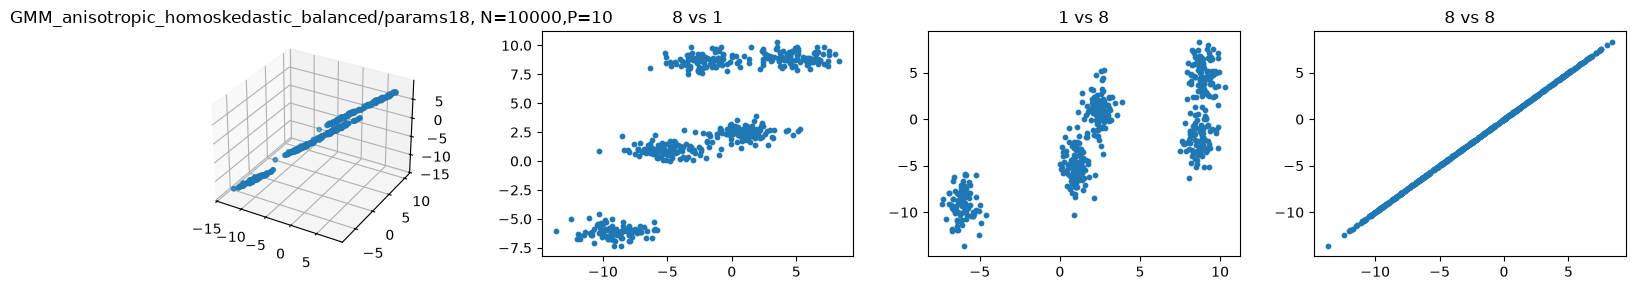

In [32]:
max_pts = 500
for r in m.groupby(["generator", "params_id"]).head(2).itertuples():
    X = np.load(Path('../all_data/')  / f"{r.dataset_id}.npy")
    if len(X) > max_pts:
        rng = np.random.default_rng(0)       
        X = X[rng.choice(len(X), max_pts, replace=False)]
    # plot_3d_scatters(X, f"{r.generator}/{r.params_id}, N={r.n_rows},P={r.n_cols}")
    plot_3d_scatters(X, f"{r.generator}/{r.params_id}, N={r.n_rows},P={r.n_cols}",custom_inx=np.random.randint(0,r.n_cols,3))

## heteroskedastic, balanced

In [25]:
data_gen_name = 'GMM_anisotropic_heteroskedastic_balanced'
category_lst = ['blobbiness']

random_seeds_lst = [100,600]

n_samples_lst = [1000,10000]
n_features_lst = [10,100,1000,10000]
# define some number of clusters according to the number of features
# {num_feature : [list of num_cluster params to sweep over]}
num_clusters_dict = {10 : [3,5,7], 100 : [3,10], 1000 : [3,10,40], 10000 : [3,10,40]}
cluster_std = 1.0
transform_sig_lst = [0.2,0.4,0.6,0.8,1]

for n_samples, n_features in product(n_samples_lst, n_features_lst):
    
    print(n_samples, n_features, X.shape)

    for n_centers in num_clusters_dict[n_features]:

        for transform_sig in transform_sig_lst:

            for sample_num,seed in enumerate(random_seeds_lst):
                
                X_iso, y = datasets.make_blobs(n_samples=n_samples,n_features=n_features, random_state=seed, centers=n_centers,cluster_std=cluster_std)
                transform_seed = seed+6
                X = diagonal_affine_transform(X_iso,y,sig=transform_sig,shared=False,seed=transform_seed)
                
                params_dict = {
                    'num_clusters': n_centers,
                    'cluster_std' : cluster_std,
                    'transform_diagonal_lognormal_sig' : transform_sig,
                    'shared_matrix_across_cluster' : False,                    
                    'transform_method' : 'generate lognormal diagonal matrix, apply affine transform, using diagonal_affine_transformation in this notebook',
                    'transform_seed' : transform_seed
                }
                
                extra_mtx_params = {
                    'cluster_labels' : y
                }
                
                try:
                    save_dataset(X, 
                                generator=data_gen_name,
                                params=params_dict,
                                seed=seed,
                                category=category_lst,
                                extra_arrays=extra_mtx_params, 
                                root='../all_data/')

                except:
                    print('error in saving')

1000 10 (500, 10)
1000 100 (1000, 10)
1000 1000 (1000, 100)
1000 10000 (1000, 1000)
10000 10 (1000, 10000)
10000 100 (10000, 10)
10000 1000 (10000, 100)
10000 10000 (10000, 1000)


In [33]:
m = pd.read_csv("../all_data/manifest.csv")
generator = 'GMM_anisotropic_heteroskedastic_balanced'
params_lst = [f'params{i}' for i in range(0,20) if i%7==2]
m = m[(m.generator == generator) & (m.params_id.isin(params_lst))]
m

,dataset_id,generator,category,n_rows,n_cols,params_id,seed,extra_files
970,GMM_anisotropic_heteroskedastic_balanced/param...,GMM_anisotropic_heteroskedastic_balanced,['blobbiness'],1000,10,params2,100,"[""cluster_labels_seed100.npy""]"
977,GMM_anisotropic_heteroskedastic_balanced/param...,GMM_anisotropic_heteroskedastic_balanced,['blobbiness'],1000,10,params9,600,"[""cluster_labels_seed600.npy""]"
984,GMM_anisotropic_heteroskedastic_balanced/param...,GMM_anisotropic_heteroskedastic_balanced,['blobbiness'],1000,10,params16,100,"[""cluster_labels_seed100.npy""]"
1000,GMM_anisotropic_heteroskedastic_balanced/param...,GMM_anisotropic_heteroskedastic_balanced,['blobbiness'],1000,100,params2,100,"[""cluster_labels_seed100.npy""]"
1007,GMM_anisotropic_heteroskedastic_balanced/param...,GMM_anisotropic_heteroskedastic_balanced,['blobbiness'],1000,100,params9,600,"[""cluster_labels_seed600.npy""]"
1020,GMM_anisotropic_heteroskedastic_balanced/param...,GMM_anisotropic_heteroskedastic_balanced,['blobbiness'],1000,1000,params2,100,"[""cluster_labels_seed100.npy""]"
1027,GMM_anisotropic_heteroskedastic_balanced/param...,GMM_anisotropic_heteroskedastic_balanced,['blobbiness'],1000,1000,params9,600,"[""cluster_labels_seed600.npy""]"
1050,GMM_anisotropic_heteroskedastic_balanced/param...,GMM_anisotropic_heteroskedastic_balanced,['blobbiness'],1000,10000,params2,100,"[""cluster_labels_seed100.npy""]"
1057,GMM_anisotropic_heteroskedastic_balanced/param...,GMM_anisotropic_heteroskedastic_balanced,['blobbiness'],1000,10000,params9,600,"[""cluster_labels_seed600.npy""]"
1080,GMM_anisotropic_heteroskedastic_balanced/param...,GMM_anisotropic_heteroskedastic_balanced,['blobbiness'],10000,10,params2,100,"[""cluster_labels_seed100.npy""]"


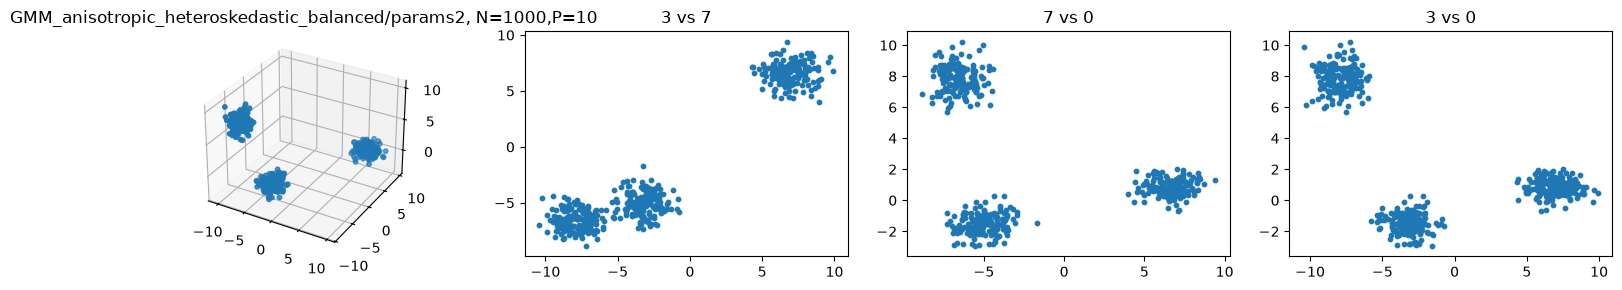

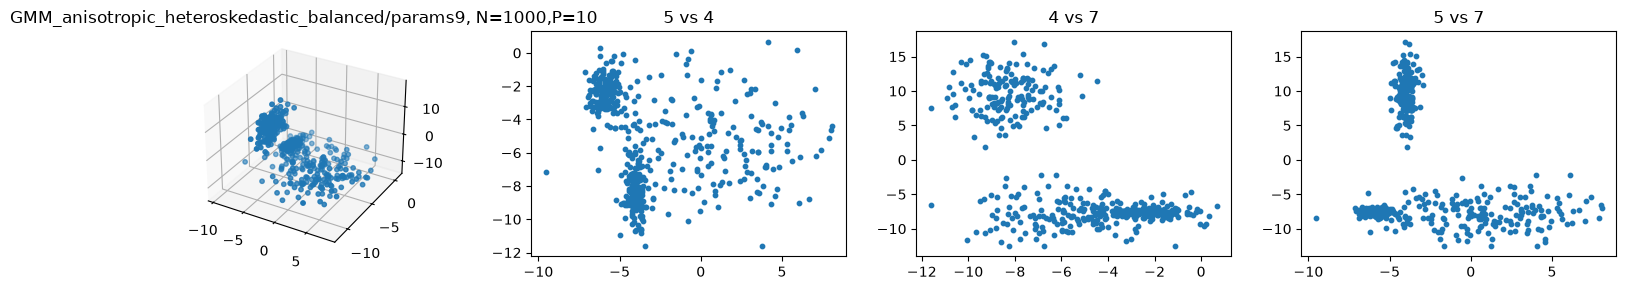

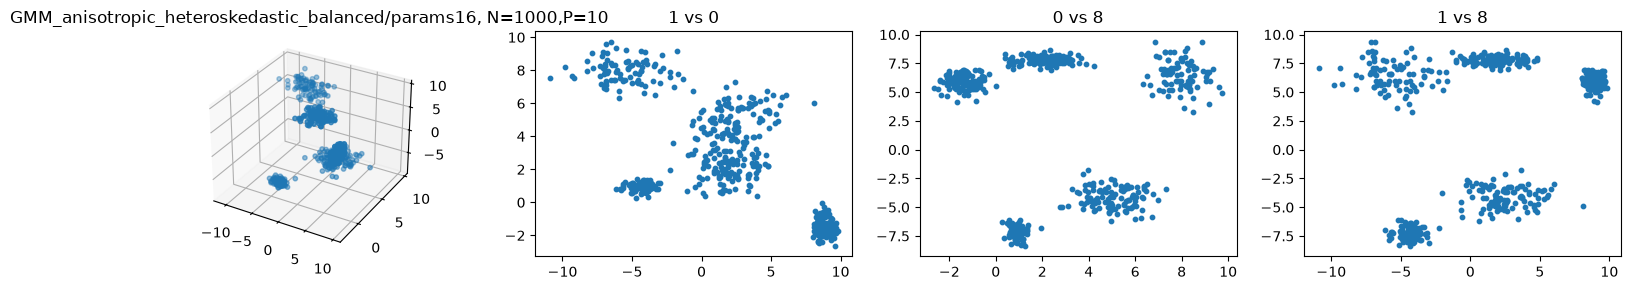

In [34]:
max_pts = 500
for r in m.groupby(["generator", "params_id"]).head(1).itertuples():
    X = np.load(Path('../all_data/')  / f"{r.dataset_id}.npy")
    if len(X) > max_pts:
        rng = np.random.default_rng(0)       
        X = X[rng.choice(len(X), max_pts, replace=False)]
    # plot_3d_scatters(X, f"{r.generator}/{r.params_id}, N={r.n_rows},P={r.n_cols}")
    plot_3d_scatters(X, f"{r.generator}/{r.params_id}, N={r.n_rows},P={r.n_cols}",custom_inx=np.random.randint(0,r.n_cols,3))

## homoskedastic and heteroskedastic, imbalanced clusters

$$w_k = \dfrac{1}{k^s}, k = 1,2,3,..K$$

w_k = cluster size proportion for cluster k, K = total number of clusters, s = hyperparameter to vary

s = 0 is when w_k = 1 (balanced case)

normalize w_k's to get proportions

as s increases, w_0 >> w_1 >> w_2 >> ..

a power law reln. (ref https://en.wikipedia.org/wiki/Power_law)

In [35]:
s = 0
n_centers = 3

def get_cluster_sizes_power_law(decay_exp, n_clusters, n_samples, min_count=20):
    """
    get decaying cluster imbalance
    currently relies on manual tuning of the decay parameter
    default: apply a min count per cluster of 20
    """
    if n_samples < min_count * n_clusters:
        raise ValueError(f"n_samples={n_samples} cannot give {n_clusters} clusters "
                         f"at least {min_count} points each")
        
    w = 1 / np.arange(1, n_clusters + 1) ** decay_exp
    w /= w.sum()
    spare = n_samples - min_count * n_clusters
    counts = min_count + np.floor(w * spare).astype(int)
    counts[0] += n_samples - counts.sum()
    return counts.tolist()


In [36]:
# get_cluster_sizes_power_law(0.5,40,1000)
# get_cluster_sizes_power_law(4,3,100)

In [ ]:
# delete_dataset('GMM_isotropic_homoskedastic_imbalanced','../all_data/')

In [37]:
category_lst = ['blobbiness']

n_samples_lst = [1000,10000]
n_features_lst = [10,100,1000,10000]
# define some number of clusters according to the number of features
# {num_feature : [list of num_cluster params to sweep over]}
num_clusters_dict = {
    10 : [3,5,7], 100 : [3,10], 
    1000 : [3,10,40], 10000 : [3,10,40]
}

# {num_cluster : [list of decay parameters]}
size_decay_dict = {
    3 : [0.5], 5 : [0.5], 7 : [0.5],
    10 : [0.5], 40 : [0.5]
}

# MORE EXTENDED, IF REQUIRED:
# size_decay_dict = {
#     3 : [0.5,1,2], 5 : [0.5,1,2], 7 : [0.5,1,2],
#     10 : [0.5,1], 40 : [0.5]
# }

cluster_std = 1.0

for is_homoskedastic in [True,False]:
    
    if is_homoskedastic:
        data_gen_name = 'GMM_anisotropic_homoskedastic_imbalanced'
        random_seeds_lst = [1056,9000]
        
    else:
        data_gen_name = 'GMM_anisotropic_heteroskedastic_imbalanced'
        random_seeds_lst = [3905,370]

    for n_samples, n_features in product(n_samples_lst, n_features_lst):
        
        print(n_samples, n_features, X.shape)

        for n_centers in num_clusters_dict[n_features]:
            
            for decay_exp in size_decay_dict[n_centers]:
                
                cluster_sizes = get_cluster_sizes_power_law(decay_exp,n_centers,n_samples)

                for transform_sig in transform_sig_lst:

                    for sample_num,seed in enumerate(random_seeds_lst):
                        
                        X_iso, y = datasets.make_blobs(n_samples=cluster_sizes,n_features=n_features, random_state=seed, centers=None,cluster_std=cluster_std)
                        transform_seed = seed+6
                        X = diagonal_affine_transform(X_iso,y,sig=transform_sig,shared=is_homoskedastic,seed=transform_seed)
                        
                        params_dict = {
                            'num_clusters': n_centers,
                            'cluster_std' : cluster_std,
                            'transform_diagonal_lognormal_sig' : transform_sig,
                            'shared_matrix_across_cluster' : is_homoskedastic,                    
                            'transform_method' : 'generate lognormal diagonal matrix, apply affine transform, using diagonal_affine_transformation in this notebook',
                            'transform_seed' : transform_seed
                        }
                        
                        extra_mtx_params = {
                            'cluster_labels' : y,
                            'cluster_sizes' : cluster_sizes
                        }
                        
                        try:
                            save_dataset(X, 
                                        generator=data_gen_name,
                                        params=params_dict,
                                        seed=seed,
                                        category=category_lst,
                                        extra_arrays=extra_mtx_params, 
                                        root='../all_data/')

                        except:
                            print('error in saving')

1000 10 (500, 10)
1000 100 (1000, 10)
1000 1000 (1000, 100)
1000 10000 (1000, 1000)
10000 10 (1000, 10000)
10000 100 (10000, 10)
10000 1000 (10000, 100)
10000 10000 (10000, 1000)
1000 10 (10000, 10000)
1000 100 (1000, 10)
1000 1000 (1000, 100)
1000 10000 (1000, 1000)
10000 10 (1000, 10000)
10000 100 (10000, 10)
10000 1000 (10000, 100)
10000 10000 (10000, 1000)


In [48]:
m = pd.read_csv("../all_data/manifest.csv")

# some manifest.csv queries
print(m.groupby(['n_rows','n_cols'])[['generator']].value_counts())

print(m.groupby(['n_rows','n_cols'])['dataset_id'].count())

n_rows  n_cols  generator                                 
1000    10      GMM_isotropic_homoskedastic_imbalanced        48
                GMM_anisotropic_homoskedastic_balanced        30
                GMM_anisotropic_heteroskedastic_balanced      30
                GMM_anisotropic_homoskedastic_imbalanced      30
                GMM_anisotropic_heteroskedastic_imbalanced    30
                                                              ..
10000   10000   GMM_isotropic_homoskedastic_balanced          24
                concentric_shells                             24
                GMM_isotropic_heteroskedastic_imbalanced      16
                GMM_isotropic_heteroskedastic_balanced        12
                isotropic_gaussian                             8
Name: count, Length: 86, dtype: int64
n_rows  n_cols
1000    10        262
        100       174
        1000      238
        10000     236
10000   10        262
        100       174
        1000      238
        10000     2

In [43]:
data_gen_name

'GMM_anisotropic_heteroskedastic_imbalanced'

In [46]:
generator = data_gen_name
params_lst = [f'params{i}' for i in range(0,100) if i%20==1]
m = m[(m.generator == generator) & (m.params_id.isin(params_lst))]
m

,dataset_id,generator,category,n_rows,n_cols,params_id,seed,extra_files
1409,GMM_anisotropic_heteroskedastic_imbalanced/par...,GMM_anisotropic_heteroskedastic_imbalanced,['blobbiness'],1000,10,params1,370,"[""cluster_labels_seed370.npy"", ""cluster_sizes_..."
1439,GMM_anisotropic_heteroskedastic_imbalanced/par...,GMM_anisotropic_heteroskedastic_imbalanced,['blobbiness'],1000,100,params1,370,"[""cluster_labels_seed370.npy"", ""cluster_sizes_..."
1459,GMM_anisotropic_heteroskedastic_imbalanced/par...,GMM_anisotropic_heteroskedastic_imbalanced,['blobbiness'],1000,1000,params1,370,"[""cluster_labels_seed370.npy"", ""cluster_sizes_..."
1479,GMM_anisotropic_heteroskedastic_imbalanced/par...,GMM_anisotropic_heteroskedastic_imbalanced,['blobbiness'],1000,1000,params41,370,"[""cluster_labels_seed370.npy"", ""cluster_sizes_..."
1489,GMM_anisotropic_heteroskedastic_imbalanced/par...,GMM_anisotropic_heteroskedastic_imbalanced,['blobbiness'],1000,10000,params1,370,"[""cluster_labels_seed370.npy"", ""cluster_sizes_..."
1509,GMM_anisotropic_heteroskedastic_imbalanced/par...,GMM_anisotropic_heteroskedastic_imbalanced,['blobbiness'],1000,10000,params41,370,"[""cluster_labels_seed370.npy"", ""cluster_sizes_..."
1519,GMM_anisotropic_heteroskedastic_imbalanced/par...,GMM_anisotropic_heteroskedastic_imbalanced,['blobbiness'],10000,10,params1,370,"[""cluster_labels_seed370.npy"", ""cluster_sizes_..."
1549,GMM_anisotropic_heteroskedastic_imbalanced/par...,GMM_anisotropic_heteroskedastic_imbalanced,['blobbiness'],10000,100,params1,370,"[""cluster_labels_seed370.npy"", ""cluster_sizes_..."
1569,GMM_anisotropic_heteroskedastic_imbalanced/par...,GMM_anisotropic_heteroskedastic_imbalanced,['blobbiness'],10000,1000,params1,370,"[""cluster_labels_seed370.npy"", ""cluster_sizes_..."
1589,GMM_anisotropic_heteroskedastic_imbalanced/par...,GMM_anisotropic_heteroskedastic_imbalanced,['blobbiness'],10000,1000,params41,370,"[""cluster_labels_seed370.npy"", ""cluster_sizes_..."


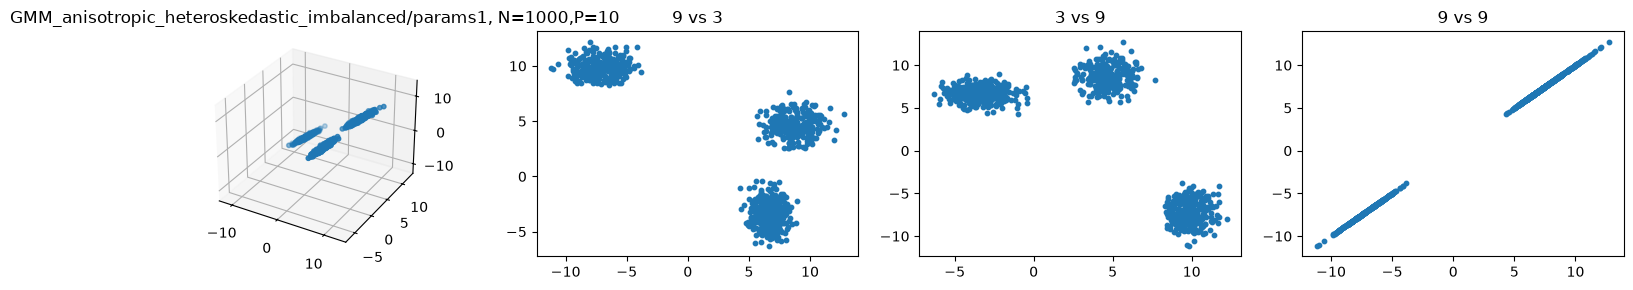

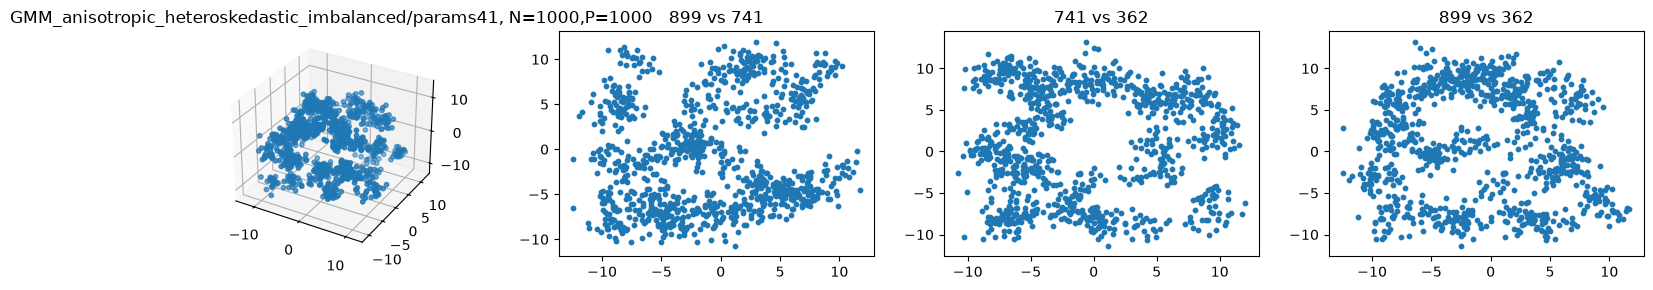

In [47]:
max_pts = 1000
for r in m.groupby(["generator", "params_id"]).head(1).itertuples():
    X = np.load(Path('../all_data/')  / f"{r.dataset_id}.npy")
    if len(X) > max_pts:
        rng = np.random.default_rng(0)       
        X = X[rng.choice(len(X), max_pts, replace=False)]
    # plot_3d_scatters(X, f"{r.generator}/{r.params_id}, N={r.n_rows},P={r.n_cols}")
    plot_3d_scatters(X, f"{r.generator}/{r.params_id}, N={r.n_rows},P={r.n_cols}",custom_inx=np.random.randint(0,r.n_cols,3))

In [ ]:
# old function, had the left_sample_prop as well but that kinda adds an unnecessary parameter
# def get_cluster_sizes_power_law(exp_decay,n_clusters,n_samples,min_count_per_cluster=10,left_sample_prop=0.5):    
    
#     """
#     get exponentially decaying cluster imbalance
#     currently relies on manual tuning of the decay parameter for 
#     default: apply a min count per cluster of 10 if doing that preserves at least 50% of samples
#     """
    
#     w = 1 / np.arange(1, n_clusters + 1) ** exp_decay  
#     norm_w = w / w.sum()
#     print(norm_w)
    
#     min_counts = np.full(n_clusters, min_count_per_cluster)
#     left_samples = n_samples - min_count_per_cluster*n_clusters        
    
#     if left_samples/n_samples > left_sample_prop:
#         counts = np.floor(norm_w * left_samples).astype(int) + min_counts
        
#     else:
#         counts = np.floor(norm_w * n_samples).astype(int)
        
#     counts[0] += n_samples - counts.sum()    
    
#     if counts.min() < 10:
#         print('min counts unreliable at this decay rate')
    
#     return counts


In [ ]:
## OLD TRANSFORM
# X,y = datasets.make_blobs(n_samples=10000,n_features=1000, centers=40,cluster_std=0.5)
# # create a random transform to stretch these blobs in diff ways and make them anisotropic
# # right now -> doing it label wise / per cluster but can also do a global transform
# unique_labels = np.unique(y)
# rng = np.random.default_rng(0)

# transforms = {
#     label: rng.normal(size=(1000, 1000))*3.0
#     for label in unique_labels
# }

# X_transformed = np.zeros_like(X)

# for label in unique_labels:
#     T = transforms[label]
#     X_transformed[y == label] = X[y == label] @ T.T
    
# plot_3d_scatters(X,'',y=y)
# plot_3d_scatters(X_transformed,'',y=y)